# Notebook 01: EDA & Data Preparation

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** A (Data & EDA, Section 2) + C (MLOps / Data Pipeline, everything else)  
**Estimated Runtime:** 2-5 minutes

---

## What this notebook does

1. Loads the crypto scam dataset and uploads the raw file to S3 (with SHA256-based versioning)
2. Exploratory Data Analysis: missing values, duplicates, class balance, platform distribution, top scam/legit terms, and a data quality & bias summary
3. Data pipeline: text cleaning, engineered indicator features, stratified train/test split, and TF-IDF vectorisation
4. EDA on the engineered features: distributions and a multicollinearity check
5. Saves the processed train/test data and the fitted TF-IDF vectorizer to S3 for Notebook 02/03

## Dataset

- Local copy: data/crypto_scam_dataset.csv
- Source: [Kaggle, Crypto Scam Dataset](https://www.kaggle.com/datasets/theeyanyan/crypto-scam-dataset/data)
- 10,466 rows, columns id, platform, text, label (scam / legit), no missing values

In [1]:
%%capture
%pip install -q --upgrade --force-reinstall "sagemaker>=2,<3" boto3 botocore
!pip install -q -U kagglehub rapidfuzz
print("Packages installed.")

## 0. Configuration

Sets up the SageMaker session, S3 bucket and prefix, and the shared random state and test size used throughout this notebook. Edit the values here; everything else references these variables.

In [2]:
import os
os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore")

import sagemaker, boto3

session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name

TEAM_ID = "team03"
BUCKET = "nyp-26s1-iti113"
PROJECT_NAME = "crypto-scam-detector"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

RANDOM_STATE = 42
TEST_SIZE = 0.20

print(f"Bucket: {BUCKET}\nPrefix: {PREFIX}\nRegion: {region}\n"
      f"Role: {role.split('/')[-1]}\nTeam ID: {TEAM_ID}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Bucket: nyp-26s1-iti113
Prefix: iti113/team03/data/crypto-scam-detector
Region: ap-southeast-1
Role: SageMakerExecutionRole-ITI113-Team03
Team ID: team03


In [3]:
import os
import io
import pandas as pd
import kagglehub

s3 = boto3.client('s3', region_name=region)

## 1. Load Dataset

The dataset is downloaded directly from Kaggle via kagglehub, so the notebook runs standalone in SageMaker Studio without needing a local repo checkout of data/crypto_scam_dataset.csv. The cell always re-downloads the dataset fresh from Kaggle, but only writes a new versioned file to S3 if the content actually changed (compared by SHA256 against the raw/_latest.json pointer). This keeps dataset-version tracking accurate, since Notebook 02 reads this same pointer file to tag every MLflow run with the dataset version it was trained on.

| Column | Description |
|--------|-------------|
| id | Unique message identifier |
| platform | Source platform (Telegram, X/Twitter, SMS, Email, Discord, Reddit) |
| text | Message content |
| label | scam or legit |

In [4]:
# Re-download from Kaggle each run, only write a new S3 version if the SHA256 content hash actually changed
import hashlib
import json

POINTER_KEY = f'{PREFIX}/raw/_latest.json'

def get_pointer():
    try:
        obj = s3.get_object(Bucket=BUCKET, Key=POINTER_KEY)
        return json.loads(obj['Body'].read())
    except s3.exceptions.NoSuchKey:
        return {"version": 0, "sha256": None, "s3_key": None}

def put_pointer(pointer):
    s3.put_object(Bucket=BUCKET, Key=POINTER_KEY, Body=json.dumps(pointer, indent=2))

dataset_path = kagglehub.dataset_download("theeyanyan/crypto-scam-dataset", force_download=True)
csv_file = os.path.join(dataset_path, "crypto_scam_dataset.csv")

with open(csv_file, "rb") as f:
    raw_bytes = f.read()
new_hash = hashlib.sha256(raw_bytes).hexdigest()

pointer = get_pointer()

if new_hash == pointer["sha256"]:
    version_note = f'No change detected. Using existing version v{pointer["version"]}: {pointer["s3_key"]}'
    RAW_S3_KEY = pointer["s3_key"]
else:
    new_version = pointer["version"] + 1
    RAW_S3_KEY = f'{PREFIX}/raw/crypto_scam_dataset_v{new_version}.csv'
    s3.put_object(Bucket=BUCKET, Key=RAW_S3_KEY, Body=raw_bytes)
    put_pointer({"version": new_version, "sha256": new_hash, "s3_key": RAW_S3_KEY})
    version_note = f'New version detected -- uploaded v{new_version}: s3://{BUCKET}/{RAW_S3_KEY}'

RAW_S3_URI = f's3://{BUCKET}/{RAW_S3_KEY}'
df_raw = pd.read_csv(io.BytesIO(raw_bytes))

print(f'{version_note}\n'
      f'Dataset sha256: {new_hash[:12]}...\n'
      f'Shape: {df_raw.shape}\n'
      f'Label counts: {df_raw["label"].value_counts().to_dict()}')
df_raw.head()

  0%|          | 0.00/568k [00:00<?, ?B/s]

100%|██████████| 568k/568k [00:00<00:00, 663kB/s]

100%|██████████| 568k/568k [00:00<00:00, 661kB/s]

Extracting files...


No change detected. Using existing version v4: iti113/team03/data/crypto-scam-detector/raw/crypto_scam_dataset_v4.csv
Dataset sha256: 31e13ac65ebc...
Shape: (10466, 4)
Label counts: {'scam': 5394, 'legit': 5072}


,id,platform,text,label
0,1,Discord,Got asked to provide a screenshot of the balan...,legit
1,2,SMS,Nadia said they could help resolve a failed ve...,legit
2,3,Email,"Guaranteed 800% profit in 10 minutes, DM me or...",scam
3,4,SMS,Someone in a Uniswap-adjacent group offered to...,scam
4,5,Email,Priya messaged offering to split a NexusFi sta...,legit


## 2. Exploratory Data Analysis

This section covers missing-value and duplicate checks, class balance (scam vs legit), platform distribution and platform-level scam rate, the top scam/legit terms, and a consolidated data quality & bias summary for the AI Governance checklist.

In [5]:
# Missing values and duplicate messages
n_missing = df_raw.isnull().sum().sum()
n_dupes = df_raw.duplicated(subset="text").sum()

print(f"Total missing values: {n_missing}\n"
      f"Duplicate messages (exact text match): {n_dupes} ({n_dupes/len(df_raw):.2%})")

Total missing values: 0
Duplicate messages (exact text match): 0 (0.00%)


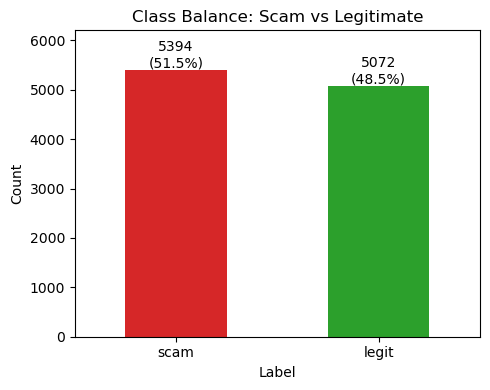

In [6]:
import matplotlib.pyplot as plt

label_counts = df_raw["label"].value_counts()
label_pct = df_raw["label"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = label_counts.plot(kind="bar", ax=ax, color=["#d62728", "#2ca02c"])
ax.bar_label(ax.containers[0], labels=[f"{c}\n({p:.1f}%)" for c, p in zip(label_counts, label_pct)])
ax.set_title("Class Balance: Scam vs Legitimate")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.margins(y=0.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

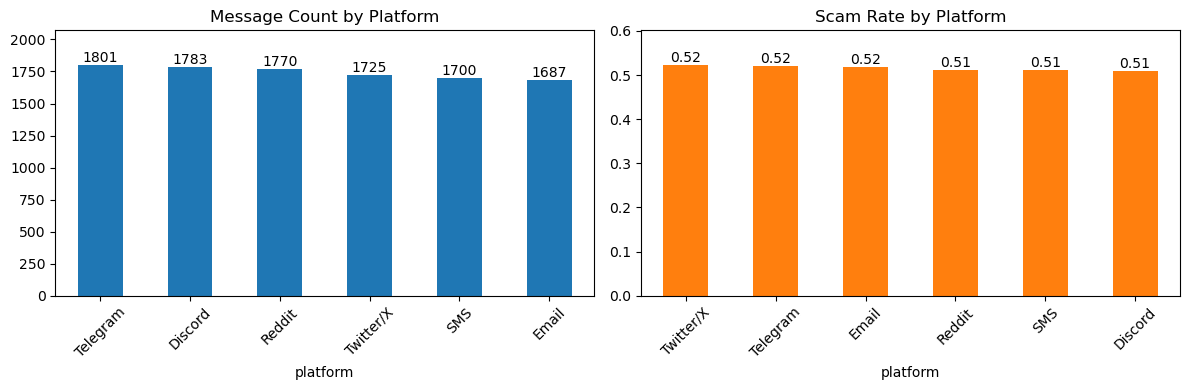

In [7]:
# Message count and scam rate by platform (checks for platform-driven bias)
platform_counts = df_raw["platform"].value_counts()
platform_scam_rate = df_raw.groupby("platform")["label"].apply(
    lambda x: (x == "scam").mean()
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

platform_counts.plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Message Count by Platform")
axes[0].tick_params(axis="x", rotation=45)
axes[0].margins(y=0.15)

platform_scam_rate.plot(kind="bar", ax=axes[1], color="#ff7f0e")
axes[1].bar_label(axes[1].containers[0], fmt="%.2f")
axes[1].set_title("Scam Rate by Platform")
axes[1].tick_params(axis="x", rotation=45)
axes[1].margins(y=0.15)

plt.tight_layout()
plt.show()

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n=3, ngram_range=(1, 1)):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, max_features=2000)
    matrix = vec.fit_transform(texts)
    freqs = matrix.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return pd.Series(freqs, index=vocab).sort_values(ascending=False).head(n)

scam_text = df_raw[df_raw["label"] == "scam"]["text"]
legit_text = df_raw[df_raw["label"] == "legit"]["text"]

print("Top 3 words in SCAM messages:")
print(top_ngrams(scam_text, n=3, ngram_range=(1, 1)))

print("\nTop 3 words in LEGIT messages:")
print(top_ngrams(legit_text, n=3, ngram_range=(1, 1)))

print("\nTop 3 bigrams in SCAM messages:")
print(top_ngrams(scam_text, n=3, ngram_range=(2, 2)))

Top 3 words in SCAM messages:
wallet     1653
account    1217
asked      1057
dtype: int64

Top 3 words in LEGIT messages:


wallet    1624
asked     1112
got       1068
dtype: int64

Top 3 bigrams in SCAM messages:
looked like          351
confirm ownership    282
like official        240
dtype: int64


**Key finding:** scam and legit messages share some of the same crypto vocabulary, both have wallet and account in their top words, so single words alone will not cleanly separate the two classes. The scam bigrams, allocations left, looked like, confirm ownership, are more distinctive and point to scarcity framing, impersonation, and requests to verify ownership. This supports pairing TF-IDF with the engineered indicator features built in Section 3, rather than relying on raw word frequency alone.

In [9]:
print(f'Data Quality & Bias Summary\n'
      f'1. Missing values: {df_raw.isnull().sum().sum()} total\n'
      f'2. Duplicate messages: {n_dupes} ({n_dupes/len(df_raw):.2%})\n'
      f'3. Class balance: {label_pct.round(1).to_dict()}\n'
      f'4. Platform coverage: {len(platform_counts)} platforms, '
      f'ranging from {platform_counts.min()} to {platform_counts.max()} messages each\n'
      f'5. Scam rate varies by platform: '
      f'{platform_scam_rate.min():.2f} to {platform_scam_rate.max():.2f}')

Data Quality & Bias Summary
1. Missing values: 0 total
2. Duplicate messages: 0 (0.00%)
3. Class balance: {'scam': 51.5, 'legit': 48.5}
4. Platform coverage: 6 platforms, ranging from 1687 to 1801 messages each
5. Scam rate varies by platform: 0.51 to 0.52


## 3. Feature Engineering & Preprocessing

This section covers text cleaning, the engineered indicator features (urgency, contact/link, structural characteristics), a stratified train/test split, and TF-IDF fitting. No feature scaling is applied, consistent with the rest of the project.

In [10]:
# Clean and normalise message text before TF-IDF vectorisation
import re

URL_PATTERN = re.compile(r"https?://[^\s]+|www\.[^\s]+")

def clean_text(text: str) -> str:
    """Normalise raw message text before TF-IDF vectorisation."""
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = URL_PATTERN.sub(" <url> ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df_raw.copy()
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,Got asked to provide a screenshot of the balan...,got asked to provide a screenshot of the balan...
1,Nadia said they could help resolve a failed ve...,nadia said they could help resolve a failed ve...
2,"Guaranteed 800% profit in 10 minutes, DM me or...","guaranteed 800% profit in 10 minutes, dm me or..."
3,Someone in a Uniswap-adjacent group offered to...,someone in a uniswap-adjacent group offered to...
4,Priya messaged offering to split a NexusFi sta...,priya messaged offering to split a nexusfi sta...


In [11]:
# Engineered indicator features (urgency, contact/link, structural), keyword lists follow the project proposal's indicator design

# General urgency/pressure tactics, common across phishing and investment fraud, not specific to crypto or this dataset
URGENT_KEYWORDS = [
    "urgent", "immediately", "hurry", "act now", "act fast", "limited time",
    "limited slots", "limited spots", "today only", "last chance",
    "final notice", "final warning", "don't miss", "don't wait",
    "expires", "expiring", "closing soon", "ending soon", "before it's too late",
    "respond now", "reply now", "confirm now", "verify now", "claim now",
    "while supplies last", "only a few left", "act before", "time-sensitive",
    "this offer", "exclusive offer", "one time offer",
]

# Unrealistic profit/return promises, a core red flag across investment fraud generally (Ponzi schemes, pump-and-dumps), not crypto-specific
GUARANTEED_RETURN_KEYWORDS = [
    "guaranteed", "guarantee", "risk-free", "risk free", "no risk",
    "zero risk", "sure profit", "sure win", "can't lose", "cannot lose",
    "double your money", "triple your money", "multiply your", "10x", "100x",
    "passive income", "easy money", "get rich", "financial freedom",
    "life-changing", "once in a lifetime", "secret method", "proven strategy",
    "insider information", "insider tip", "exclusive access", "vip access",
]

# Payment/transfer requests, a general fraud indicator also seen in romance scams and tech-support scams, phrased broadly
PAYMENT_KEYWORDS = [
    "deposit", "transfer", "send funds", "send payment", "send money",
    "top up", "top-up", "processing fee", "activation fee", "unlock fee",
    "advance fee", "small fee", "gas fee", "network fee", "wallet",
    "crypto", "bitcoin", "ethereum", "usdt", "stablecoin",
]

# Off-platform redirection, a general grooming/scam pattern that moves victims away from a platform's moderation and paper trail
OFF_PLATFORM_KEYWORDS = [
    "telegram", "whatsapp", "discord", "signal", "wechat", "line app",
    "private chat", "private message", "dm me", "direct message",
    "text me", "call me", "contact me directly", "reach out privately",
    "add me on",
]

# Credential/secret-harvesting requests, a general phishing red flag across bank, email, and crypto wallet takeovers alike
CREDENTIAL_KEYWORDS = [
    "seed phrase", "private key", "recovery phrase", "recovery key",
    "wallet password", "login credentials", "verification code", "otp",
    "security code", "pin number", "social security"
]

WALLET_PATTERN = re.compile(r"\b(?:0x[a-fA-F0-9]{40}|[13][a-km-zA-HJ-NP-Z1-9]{25,34})\b")
EMAIL_PATTERN = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
PHONE_PATTERN = re.compile(r"(?:\+?\d[\d\s-]{7,}\d)")
COUNTDOWN_PATTERN = re.compile(r"\b\d+\s*(?:hour|hours|hr|hrs|minute|minutes|min|mins|day|days)\b", re.IGNORECASE)

# Fuzzy matcher, tolerates typos generically (no dataset-specific fixes)
from rapidfuzz import fuzz

def find_keyword_matches_fuzzy(message: str, keywords: list, threshold: int = 85) -> list:
    """Typo-tolerant match, token-level ratio for single words, partial_ratio for phrases."""
    message_lower = message.lower()
    tokens = message_lower.split()
    matches = []
    for kw in keywords:
        kw_lower = kw.lower()
        if " " in kw_lower:
            if fuzz.partial_ratio(kw_lower, message_lower) >= threshold:
                matches.append(kw)
        else:
            if any(fuzz.ratio(kw_lower, tok) >= threshold for tok in tokens):
                matches.append(kw)
    return matches

def extract_engineered_features(text: str) -> dict:
    if not isinstance(text, str):
        text = ""

    urgency_keyword_hits = len(find_keyword_matches_fuzzy(text, URGENT_KEYWORDS))
    guaranteed_return_hits = len(find_keyword_matches_fuzzy(text, GUARANTEED_RETURN_KEYWORDS))
    countdown_hits = len(COUNTDOWN_PATTERN.findall(text))
    exclamation_count = text.count("!")
    urgency_score = urgency_keyword_hits + countdown_hits + min(exclamation_count, 3)

    wallet_matches = WALLET_PATTERN.findall(text)
    url_matches = URL_PATTERN.findall(text)
    email_matches = EMAIL_PATTERN.findall(text)
    phone_matches = PHONE_PATTERN.findall(text)
    payment_hits = len(find_keyword_matches_fuzzy(text, PAYMENT_KEYWORDS))
    off_platform_hits = len(find_keyword_matches_fuzzy(text, OFF_PLATFORM_KEYWORDS))
    credential_hits = len(find_keyword_matches_fuzzy(text, CREDENTIAL_KEYWORDS))

    letters = [c for c in text if c.isalpha()]
    capital_ratio = sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0
    digit_count = sum(1 for c in text if c.isdigit())

    return {
        "urgency_keyword_count": urgency_keyword_hits,
        "guaranteed_return_keyword_count": guaranteed_return_hits,
        "countdown_phrase_count": countdown_hits,
        "exclamation_count": exclamation_count,
        "urgency_score": urgency_score,
        "has_wallet_address": int(bool(wallet_matches)),
        "has_url": int(bool(url_matches)),
        "url_count": len(url_matches),
        "has_email": int(bool(email_matches)),
        "has_phone_number": int(bool(phone_matches)),
        "payment_keyword_count": payment_hits,
        "off_platform_keyword_count": off_platform_hits,
        "credential_keyword_count": credential_hits,
        "capital_letter_ratio": round(capital_ratio, 4),
        "has_numeric_content": int(digit_count > 0),
    }

engineered = pd.DataFrame([extract_engineered_features(t) for t in df["text"]], index=df.index)
ENGINEERED_COLS = list(engineered.columns)
df = pd.concat([df, engineered], axis=1)
df[ENGINEERED_COLS].head()

,urgency_keyword_count,guaranteed_return_keyword_count,countdown_phrase_count,exclamation_count,urgency_score,has_wallet_address,has_url,url_count,has_email,has_phone_number,payment_keyword_count,off_platform_keyword_count,credential_keyword_count,capital_letter_ratio,has_numeric_content
0,0,0,0,0,0,1,0,0,0,0,1,0,0,0.0091,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0250,0
2,0,2,1,0,1,0,0,0,0,1,0,1,0,0.0588,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0215,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0429,1


In [12]:
# Stratified train/test split on label
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

print(f'Train: {train_df.shape[0]} rows, scam rate {(train_df["label"]=="scam").mean():.3f}\n'
      f'Test: {test_df.shape[0]} rows, scam rate {(test_df["label"]=="scam").mean():.3f}\n'
      f'Full dataset scam rate: {(df_raw["label"]=="scam").mean():.3f} (stratification confirmed)')

Train: 8372 rows, scam rate 0.515
Test: 2094 rows, scam rate 0.515
Full dataset scam rate: 0.515 (stratification confirmed)


In [13]:
# Fit TF-IDF vectorizer, important: fit on TRAIN text only, never on test
from sklearn.feature_extraction.text import TfidfVectorizer

# Default (no stopword removal), used as the baseline going forward
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
vectorizer.fit(train_df["clean_text"])

# With English stopwords removed, comparison only
vectorizer_no_stop = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=2, stop_words="english"
)
vectorizer_no_stop.fit(train_df["clean_text"])

# Check whether removing stopwords drops any scam-relevant phrases
vocab_default = set(vectorizer.get_feature_names_out())
vocab_no_stop = set(vectorizer_no_stop.get_feature_names_out())
dropped = vocab_default - vocab_no_stop
scam_relevant_keywords = set(
    kw.lower() for kw in URGENT_KEYWORDS + GUARANTEED_RETURN_KEYWORDS + PAYMENT_KEYWORDS
)
overlap = {term for term in dropped if any(term in kw or kw in term for kw in scam_relevant_keywords)}

print(f'Vocabulary size: {len(vocab_default)} (no stopword removal), '
      f'{len(vocab_no_stop)} (with stopword removal)\n'
      f'Terms dropped by stopword removal: {len(dropped)}, '
      f'{len(overlap)} of which overlap the scam keyword lists')

Vocabulary size: 5000 (no stopword removal), 5000 (with stopword removal)
Terms dropped by stopword removal: 2567, 97 of which overlap the scam keyword lists


## 4. Engineered Features EDA

This section looks at the distributions of the engineered indicator features across the train set and checks for multicollinearity between them.

In [14]:
import seaborn as sns

# has_url and url_count excluded, both are 0 for every message (zero variance), so they add nothing to the plots below
BINARY_FEATURES = [
    "has_wallet_address", "has_email",
    "has_phone_number", "has_numeric_content",
]

CONTINUOUS_FEATURES = [
    "urgency_keyword_count", "guaranteed_return_keyword_count", "countdown_phrase_count",
    "exclamation_count", "urgency_score",
    "payment_keyword_count", "off_platform_keyword_count", "credential_keyword_count",
    "capital_letter_ratio",
]

ALL_FEATURES = BINARY_FEATURES + CONTINUOUS_FEATURES

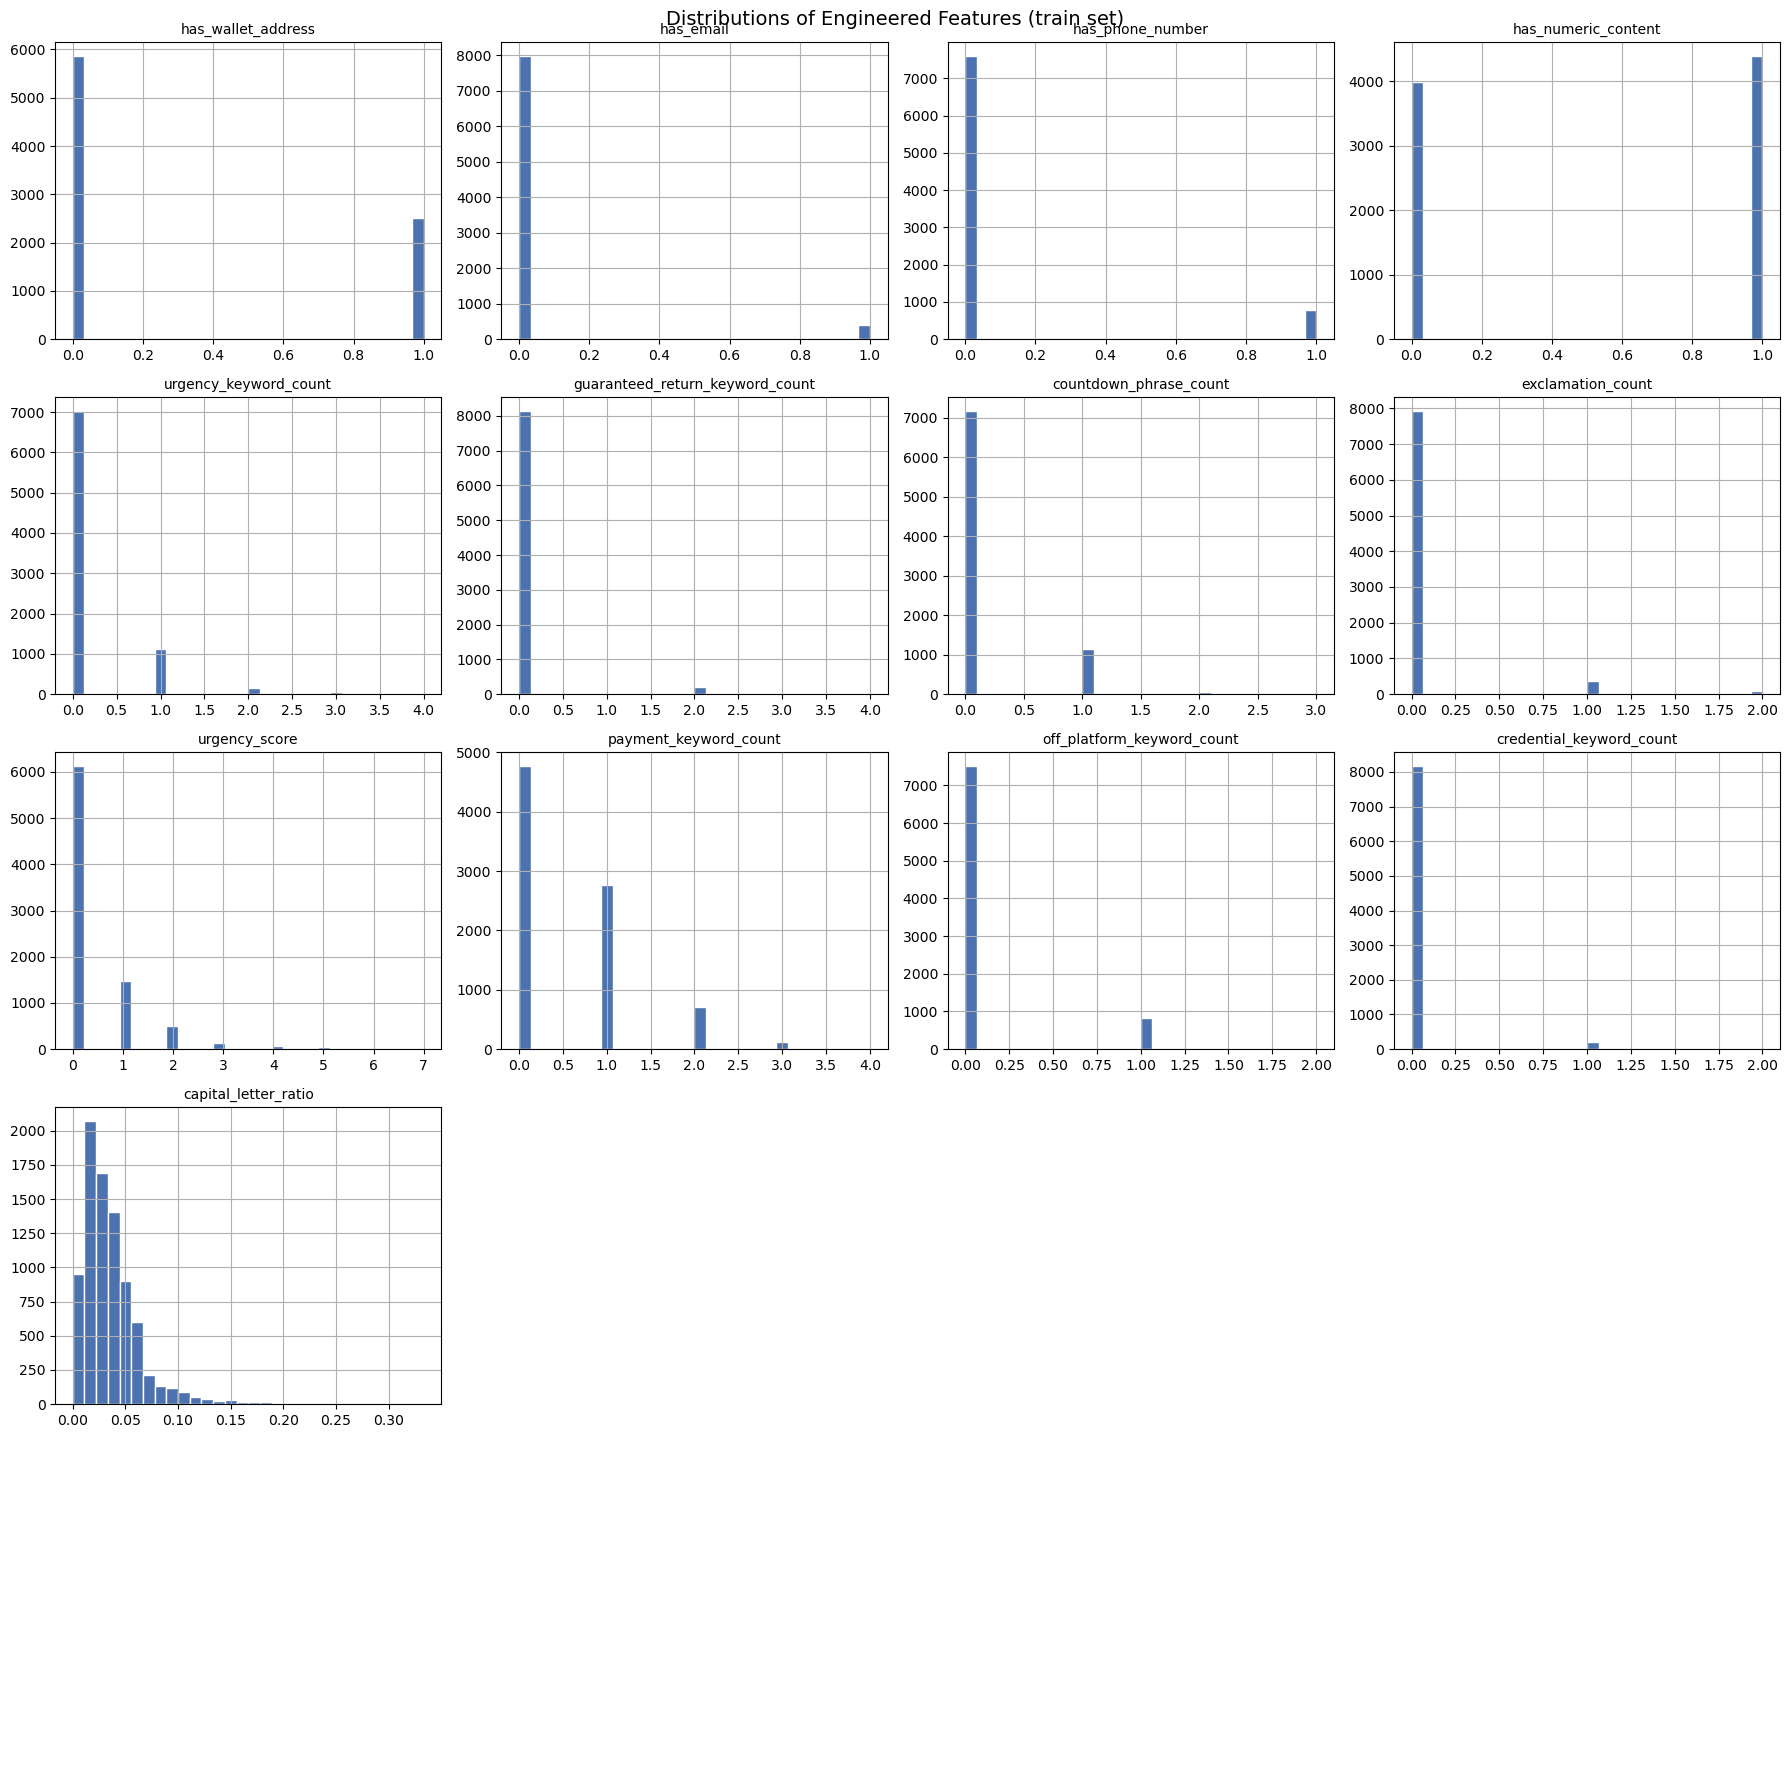

In [15]:
# Distributions of engineered features across the train set
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()

for ax, feat in zip(axes, ALL_FEATURES):
    train_df[feat].hist(bins=30, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(feat, fontsize=10)

for ax in axes[len(ALL_FEATURES):]:
    ax.axis("off")

plt.suptitle("Distributions of Engineered Features (train set)", fontsize=14)
plt.tight_layout()
plt.show()

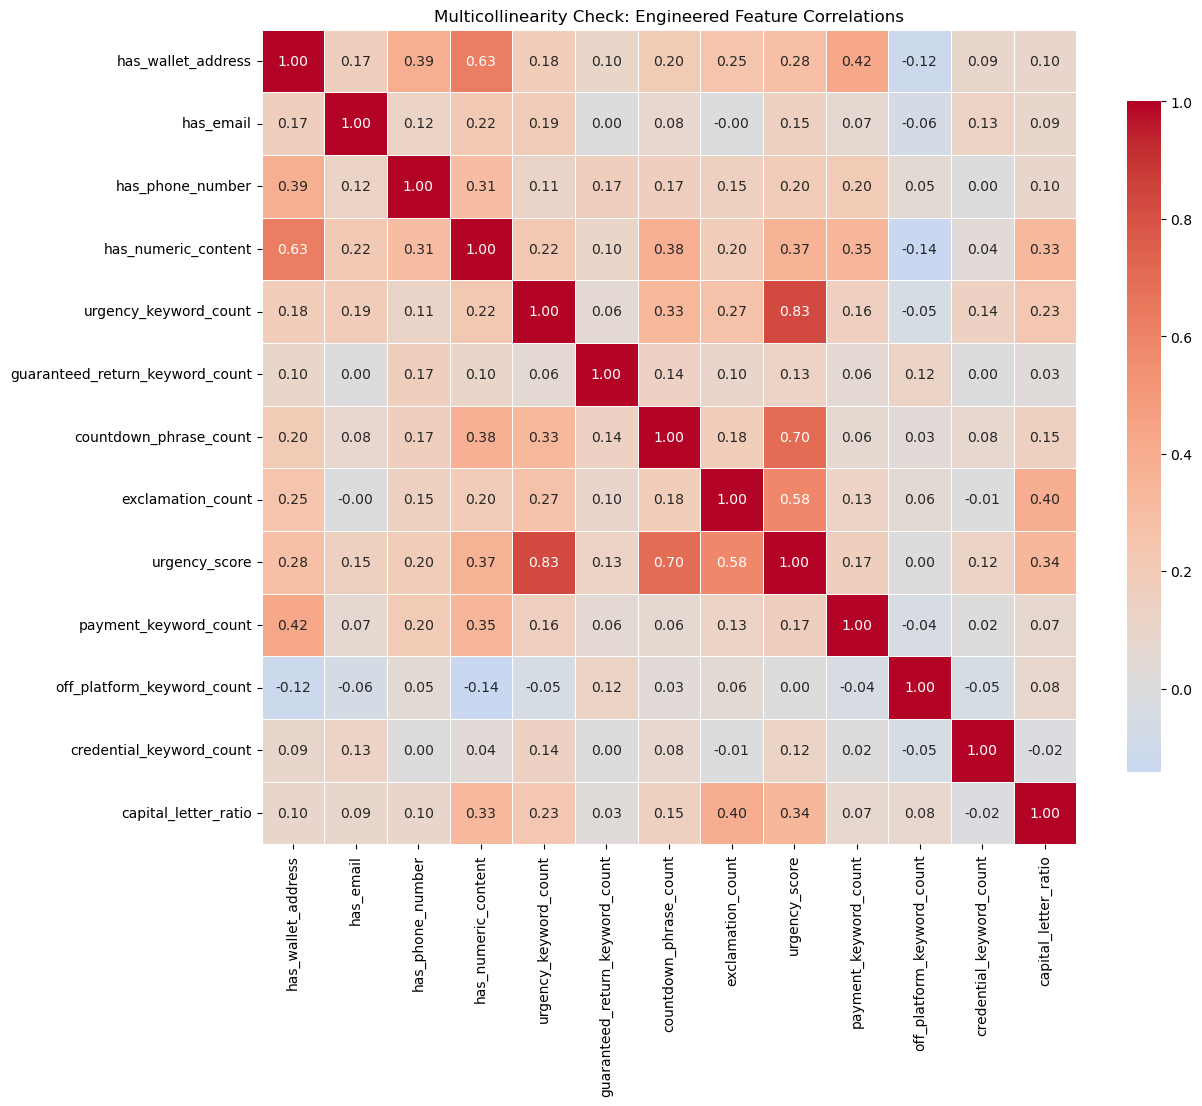

In [16]:
# Correlation heatmap (multicollinearity check)
feature_corr = train_df[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    feature_corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Multicollinearity Check: Engineered Feature Correlations")
plt.tight_layout()
plt.show()

## 5. Save Processed Data to S3

Uploads the processed train/test splits and the fitted TF-IDF vectorizer to S3 for Notebook 02/03 to consume.

In [17]:
# Saves train/test splits (text, engineered features, label) and the fitted TF-IDF vectorizer as three artifacts
import joblib
import tempfile

def save_csv_to_s3(df, bucket, key):
    buf = io.StringIO()
    df.to_csv(buf, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    return f's3://{bucket}/{key}'

def save_joblib_to_s3(obj, bucket, key):
    with tempfile.NamedTemporaryFile(suffix='.joblib') as tmp:
        joblib.dump(obj, tmp.name)
        s3.upload_file(tmp.name, bucket, key)
    return f's3://{bucket}/{key}'

p = f'{PREFIX}/processed'
paths = {
    'train': save_csv_to_s3(train_df, BUCKET, f'{p}/train.csv'),
    'test': save_csv_to_s3(test_df, BUCKET, f'{p}/test.csv'),
    'tfidf_vectorizer': save_joblib_to_s3(vectorizer, BUCKET, f'{p}/tfidf_vectorizer.joblib'),
}

print('Saved to ' + f's3://{BUCKET}/{p}' + ':\n' +
      '\n'.join(f'  {name}: {uri}' for name, uri in paths.items()))

Saved to s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed:
  train: s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/train.csv
  test: s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/test.csv
  tfidf_vectorizer: s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/tfidf_vectorizer.joblib


In [18]:
# Lists only this notebook's own artifacts (raw + processed)
import boto3

s3 = boto3.client('s3')

for sub_prefix in ('raw/', 'processed/'):
    full_prefix = f'iti113/team03/data/crypto-scam-detector/{sub_prefix}'
    response = s3.list_objects_v2(Bucket='nyp-26s1-iti113', Prefix=full_prefix)
    objects = response.get('Contents', [])
    print(f'{sub_prefix} ({len(objects)} objects):')
    for obj in objects:
        print(f"  {obj['Key'].removeprefix(full_prefix)} ({obj['Size']} bytes, modified: {obj['LastModified']})")

raw/ (6 objects):
  _latest.json (184 bytes, modified: 2026-08-14 07:35:27+00:00)
  crypto_scam_dataset.csv (2229056 bytes, modified: 2026-08-13 15:36:42+00:00)
  crypto_scam_dataset_v1.csv (2459488 bytes, modified: 2026-08-09 09:06:24+00:00)
  crypto_scam_dataset_v2.csv (2229056 bytes, modified: 2026-08-13 16:00:43+00:00)
  crypto_scam_dataset_v3.csv (2673279 bytes, modified: 2026-08-13 16:55:35+00:00)
  crypto_scam_dataset_v4.csv (2229056 bytes, modified: 2026-08-14 07:35:27+00:00)
processed/ (3 objects):
  test.csv (939558 bytes, modified: 2026-08-15 05:51:21+00:00)
  tfidf_vectorizer.joblib (199281 bytes, modified: 2026-08-15 05:51:21+00:00)
  train.csv (3696687 bytes, modified: 2026-08-15 05:51:21+00:00)
